# Knowledge Graph Tutorial 

### Raw data

In [1]:
text = """
Albert Einstein was born in Germany.
Albert Einstein worked at Princeton University.
Marie Curie was born in Poland.
Marie Curie won the Nobel Prize.
"""

### Extract entities (NER)

In [2]:
import spacy

nlp = spacy.load("en_core_web_sm")

doc = nlp(text)

entities = [(ent.text, ent.label_) for ent in doc.ents]

print(entities)

[('Albert Einstein', 'PERSON'), ('Germany', 'GPE'), ('Albert Einstein', 'PERSON'), ('Princeton University', 'ORG'), ('Marie Curie', 'PERSON'), ('Poland', 'GPE'), ('Marie Curie', 'PERSON'), ('the Nobel Prize', 'WORK_OF_ART')]


### Simple relation extraction

In [3]:
triples = []

for sent in doc.sents:
    sent_doc = nlp(sent.text)
    
    persons = [ent.text for ent in sent_doc.ents if ent.label_ == "PERSON"]
    locations = [ent.text for ent in sent_doc.ents if ent.label_ in ["GPE"]]
    
    if "born" in sent.text and persons and locations:
        triples.append((persons[0], "born_in", locations[0]))
        
    if "worked" in sent.text:
        orgs = [ent.text for ent in sent_doc.ents if ent.label_ == "ORG"]
        if persons and orgs:
            triples.append((persons[0], "worked_at", orgs[0]))

print(triples)

[('Albert Einstein', 'born_in', 'Germany'), ('Albert Einstein', 'worked_at', 'Princeton University'), ('Marie Curie', 'born_in', 'Poland')]


### Build the knowledge graph

In [4]:
import networkx as nx

G = nx.DiGraph()

for h, r, t in triples:
    G.add_edge(h, t, relation=r)

print(G.edges(data=True))

[('Albert Einstein', 'Germany', {'relation': 'born_in'}), ('Albert Einstein', 'Princeton University', {'relation': 'worked_at'}), ('Marie Curie', 'Poland', {'relation': 'born_in'})]


### Save triples for embedding training

In [15]:
import pandas as pd

df = pd.DataFrame(triples, columns=["head", "relation", "tail"])
df.to_csv("data/kg_triples.tsv", sep="\t", index=False, header=False)

### Train knowledge graph embeddings

In [21]:
from pykeen.pipeline import pipeline
from pykeen.triples import TriplesFactory

# Load your triples
tf = TriplesFactory.from_path("data/kg_triples.tsv")

# For tiny datasets, just split manually (80/20 or copy everything to testing)
# Here we simply use the same tf for training and testing for demo purposes
training_tf = tf
testing_tf = tf  # toy example, same triples

# Run pipeline
result = pipeline(
    training=training_tf,
    testing=testing_tf,
    model="TransE",
    training_kwargs=dict(num_epochs=50),
)

print("Training complete")
print(result.model)

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
/home/iqujeff/anaconda3/envs/kg-tutorial/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training epochs on cpu:   0%|          | 0/50 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/1.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/1.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/1.00 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/1.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/1.00 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/12.0 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.06s seconds


Training complete
TransE(
  (loss): MarginRankingLoss(
    (margin_activation): ReLU()
  )
  (interaction): TransEInteraction()
  (entity_representations): ModuleList(
    (0): Embedding(
      (_embeddings): Embedding(13, 50)
    )
  )
  (relation_representations): ModuleList(
    (0): Embedding(
      (_embeddings): Embedding(4, 50)
    )
  )
  (weight_regularizers): ModuleList()
)


### Query the trained model

#### predict the head entity

#### Missing relations

### Visualizing the graph

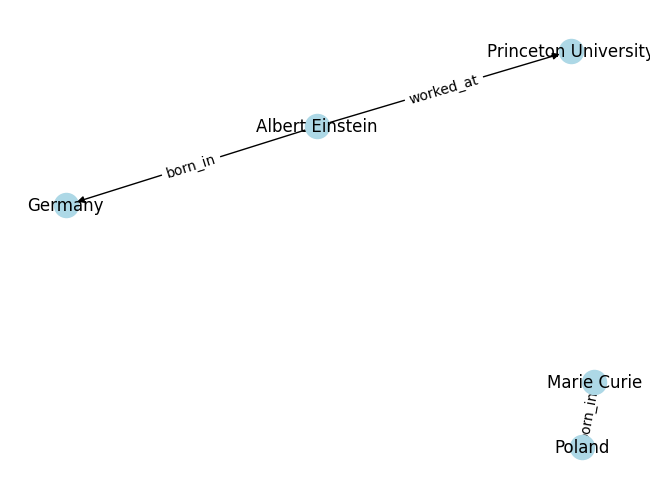

In [24]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_color="lightblue")

edge_labels = nx.get_edge_attributes(G,'relation')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.show()